In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import glv

In [2]:
# --- Parameters ---
N = 1000
C = 50
sigma = 0.2
tau_max = 1e6
n_mu = 40
n_reps = 10

# --- Exponential degree sequence ---
degree_sequence = np.maximum(np.random.exponential(scale=C, size=N).astype(int), 1)
if np.sum(degree_sequence) % 2 != 0:
    degree_sequence[0] += 1

# --- Theoretical mu_c ---
nu_pdf = lambda g: np.exp(-g)
mu_c = glv.calculate_mu_c(sigma=sigma, gamma=0.0, nu_pdf=nu_pdf)["mu_c"]
print(f"mu_c (theoretical) = {mu_c:.4f}")

# --- Build adjacency matrix ---
G = nx.Graph(nx.configuration_model(list(degree_sequence)))
G.remove_edges_from(nx.selfloop_edges(G))
A = nx.to_scipy_sparse_array(G, format="csr", dtype=float)

# --- Initial conditions ---
initial_conditions = []
for _ in range(n_reps):
    x_initial = np.random.uniform(0.1, 1.0, N)
    M_0 = np.sum(x_initial)
    y_0 = x_initial / M_0
    initial_conditions.append(np.concatenate((y_0, [M_0], [0.0])))

# --- Find empirical mu_c ---
mu_c_emp = glv.find_empirical_mu_c(
    mu_c_theoretical=mu_c,
    A=A,
    C=C,
    sigma=sigma,
    initial_conditions=initial_conditions,
    n_mu=n_mu,
    tau_max=tau_max,
    n_workers=4,
)
print(f"mu_c (empirical)    = {mu_c_emp:.4f}")

mu_c (theoretical) = 0.4990
mu_c (empirical)    = 0.5898


In [ ]:
import multiprocessing as mp

# --- Parameters ---
RUN_DIST        = True
n_dist          = 50
n_reps_dist     = 3
n_mu_dist       = 15
n_outer_workers = 2


def _dist_worker(seed):
    rng = np.random.default_rng(seed)

    ds = np.maximum(rng.exponential(scale=C, size=N).astype(int), 1)
    if np.sum(ds) % 2 != 0:
        ds[0] += 1

    G_i = nx.Graph(nx.configuration_model(list(ds)))
    G_i.remove_edges_from(nx.selfloop_edges(G_i))
    A_i = nx.to_scipy_sparse_array(G_i, format="csr", dtype=float)

    ics = []
    for _ in range(n_reps_dist):
        x0 = rng.uniform(0.1, 1.0, N)
        M0 = float(x0.sum())
        ics.append(np.concatenate((x0 / M0, [M0], [0.0])))

    try:
        mu_mid = glv.find_empirical_mu_c(
            mu_c_theoretical=mu_c,
            A=A_i,
            C=C,
            sigma=sigma,
            initial_conditions=ics,
            n_mu=n_mu_dist,
            tau_max=tau_max,
            method="RK45",
            n_workers=1,
        )
        return float(mu_mid - mu_c)
    except RuntimeError:
        return None


if RUN_DIST:
    seeds   = np.random.randint(0, 2**31, size=n_dist).tolist()
    results = []

    ctx = mp.get_context('fork')
    with ctx.Pool(processes=n_outer_workers) as pool:
        for i, r in enumerate(pool.imap_unordered(_dist_worker, seeds)):
            if r is not None:
                results.append(r)
            if (i + 1) % 100 == 0:
                print(f"{i+1}/{n_dist}  successful fits: {len(results)}")

    deltas = np.array(results)
    print(f"Successful fits: {len(deltas)}/{n_dist}")
    print(f"mean(mu_mid - mu_c) = {deltas.mean():.4f},  std = {deltas.std():.4f}")

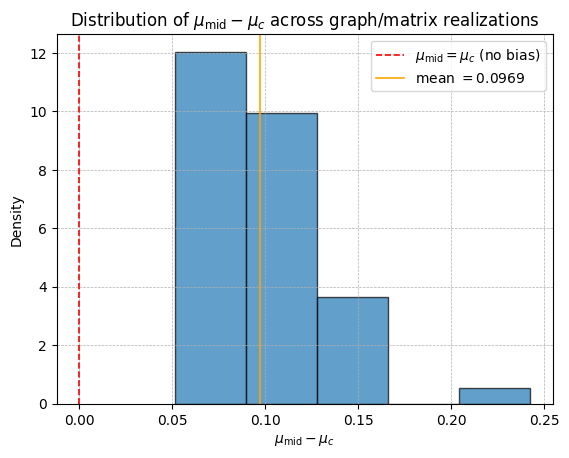

In [11]:
fig, ax = plt.subplots()
ax.hist(deltas, bins=5, density=True, alpha=0.7, edgecolor='k')
ax.axvline(0, color='red', linestyle='--', linewidth=1.2,
           label=r'$\mu_{\mathrm{mid}} = \mu_c$ (no bias)')
ax.axvline(deltas.mean(), color='orange', linestyle='-', linewidth=1.2,
           label=fr'mean $= {deltas.mean():.4f}$')
ax.set_xlabel(r'$\mu_{\mathrm{mid}} - \mu_c$')
ax.set_ylabel('Density')
ax.set_title(r'Distribution of $\mu_{\mathrm{mid}} - \mu_c$ across graph/matrix realizations')
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5)
plt.show()
